# TP2 Starter Pack: Image-to-Prompt Inversion

This notebook provides the basic utilities needed for TP2:

- mount Google Drive in Colab / VS Code Colab extension;
- load the TP2 target images;
- extract the fixed render seed from each target filename;
- load the LCM generator `SimianLuo/LCM_Dreamshaper_v7`;
- generate images from prompts using the same settings as the target images;
- save generated images and metadata.

The goal of TP2 is to find prompts that reproduce the target images as closely as possible when rendered with the same LCM setup.


## 1. Install Dependencies

For local runs, create and activate a clean conda environment first, then install the dependencies in this order:

```powershell
conda create -n GEN_AI_TP2 python=3.11 -y
conda activate GEN_AI_TP2
conda install pytorch pytorch-cuda=12.1 -c pytorch -c nvidia -y
python -m pip install "sympy==1.13.1"
python -m pip install "diffusers==0.35.2" "transformers<5" accelerate safetensors matplotlib torchvision==0.20.1 ipywidgets "pandas<3" "Pillow<12" numpy
```

Then select that conda environment as the notebook kernel and run the cells below.

For **Colab**: uses the default Colab runtime Python.

The notebook installer cell is only a fallback/check for missing Python packages.


In [ ]:
# Safe installer for local runs. Set SKIP_INSTALL = True to skip installation.
# This cell assumes the conda environment was already created, activated, and has CUDA-enabled PyTorch installed.
SKIP_INSTALL = globals().get("SKIP_INSTALL", False)
if SKIP_INSTALL:
    print('SKIP_INSTALL=True — skipping package installation')
else:
    import importlib, subprocess, sys

    def ensure(pkg):
        name = pkg.split('[')[0].split('<')[0].split('==')[0]
        try:
            importlib.import_module(name)
            return False
        except Exception:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
            return True

    pkgs = [
        "numpy",
        "sympy==1.13.1",
        "diffusers==0.35.2",
        "transformers<5",
        "accelerate",
        "safetensors",
        "matplotlib",
        "torchvision==0.20.1",
        "ipywidgets",
        "pandas<3",
        "Pillow<12",
    ]

    installed_any = False
    for p in pkgs:
        try:
            installed_any |= ensure(p)
        except Exception as e:
            print('Failed to install', p, ':', e)

    if installed_any:
        print('Installed missing packages — restart the kernel before heavy imports.')
    else:
        print('All required packages already installed.')


In [1]:
import sys
import torch
print(sys.executable)
print(torch.__version__)
print(getattr(torch.version,'cuda',None))
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/usr/bin/python3
2.11.0+cu128
12.8
True
Using device: cuda


## 2. Google Drive and Target Paths

The notebook avoids the Colab upload widget, which is unreliable in the VS Code Colab extension.

Recommended Drive layout:

```text
MyDrive/GENAI_TP2/tp2-chosen/*.png
```

Alternative: place `tp2-chosen.zip` in `MyDrive/GENAI_TP2/`.


In [2]:
from pathlib import Path
import zipfile
import urllib.request

# Default to local execution. Set True if you want to mount Google Drive (Colab).
MOUNT_GOOGLE_DRIVE = False

if MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print("Google Drive mount skipped:", exc)

# Optional online URL for a zip with the target images.
TARGETS_ZIP_URL = ""

CONTENT_DIR = Path("/content")
DRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_PROJECT_DIR = DRIVE_ROOT / "GENAI_TP2"
LOCAL_PROJECT_DIR = CONTENT_DIR / "GENAI_TP2" if CONTENT_DIR.exists() else Path("students")

# Output dir: prefer local project outputs unless mounting Drive
if DRIVE_ROOT.exists() and MOUNT_GOOGLE_DRIVE:
    DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs"
elif CONTENT_DIR.exists():
    OUTPUT_DIR = CONTENT_DIR / "tp2_outputs"
else:
    OUTPUT_DIR = Path("students/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

def list_target_images(path):
    path = Path(path)
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        return [path]
    if not path.exists():
        return []
    return sorted(p for p in path.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)

# Prefer project-local folders first
TARGET_DIR_CANDIDATES = [
    Path("tp2-chosen"),
    Path("students/tp2-chosen"),
    Path("/content/tp2-chosen"),
    Path("/content/tp2_targets"),
]
if MOUNT_GOOGLE_DRIVE:
    TARGET_DIR_CANDIDATES += [
        DRIVE_PROJECT_DIR / "tp2-chosen",
        Path("/content/drive/MyDrive/tp2-chosen"),
        Path("/content/drive/MyDrive/tp2_targets"),
    ]

ZIP_CANDIDATES = [
    Path("tp2-chosen.zip"),
    Path("students/tp2-chosen.zip"),
    Path("/content/tp2-chosen.zip"),
]
if MOUNT_GOOGLE_DRIVE:
    ZIP_CANDIDATES += [DRIVE_PROJECT_DIR / "tp2-chosen.zip", Path("/content/drive/MyDrive/tp2-chosen.zip")]

# Download optional online zip.
if TARGETS_ZIP_URL:
    LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_zip = LOCAL_PROJECT_DIR / "tp2-chosen.zip"
    urllib.request.urlretrieve(TARGETS_ZIP_URL, downloaded_zip)
    ZIP_CANDIDATES.insert(0, downloaded_zip)
    print("Downloaded targets zip to", downloaded_zip)

# Extract first available zip if no folder with images exists yet.
if not any(list_target_images(candidate) for candidate in TARGET_DIR_CANDIDATES):
    for zip_path in ZIP_CANDIDATES:
        if zip_path.exists():
            extract_dir = Path("/content/tp2-chosen") if CONTENT_DIR.exists() else Path("tp2-chosen")
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(extract_dir)
            print(f"Extracted {zip_path} -> {extract_dir}")
            break

TARGET_DIR = None
for candidate in TARGET_DIR_CANDIDATES:
    if list_target_images(candidate):
        TARGET_DIR = candidate
        break

if TARGET_DIR is None:
    raise FileNotFoundError(
        "No target images found. Put images in tp2-chosen/ (project root) or students/tp2-chosen/, "
        "or put tp2-chosen.zip in the project root, or set TARGETS_ZIP_URL."
    )

target_images = list_target_images(TARGET_DIR)
print("Target folder:", TARGET_DIR)
print("Output folder:", OUTPUT_DIR)
print("Number of targets:", len(target_images))
target_images

Target folder: tp2-chosen
Output folder: /content/tp2_outputs
Number of targets: 6


[PosixPath('tp2-chosen/1159_25.png'),
 PosixPath('tp2-chosen/1159_29.png'),
 PosixPath('tp2-chosen/1159_3.png'),
 PosixPath('tp2-chosen/1159_7.png'),
 PosixPath('tp2-chosen/7836.png'),
 PosixPath('tp2-chosen/9338.png')]

## 3. Utilities: Seeds, Display, and Output Folders

The target filename encodes the render seed:

- `7836.png` uses seed `7836`;
- `1159_25.png` uses seed `1159`.


In [3]:
import csv
import json
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image


def seed_from_filename(path, fallback=2026):
    match = re.match(r"^(\d+)", Path(path).stem)
    return int(match.group(1)) if match else fallback


def safe_stem(path):
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in Path(path).stem)


def load_image(path):
    return Image.open(path).convert("RGB")


def create_run_dir(base_dir=OUTPUT_DIR, identity="student_run"):
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = Path(base_dir) / f"{timestamp}_{identity}"
    run_dir.mkdir(parents=True, exist_ok=False)
    return run_dir


def write_csv(path, rows):
    rows = list(rows)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        Path(path).write_text("")
        return
    fieldnames = []
    for row in rows:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)
    with open(path, "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def show_images(paths, cols=3, title=None):
    paths = list(paths)
    if not paths:
        print("No images to show.")
        return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    for ax in [ax for row in axes for ax in row]:
        ax.axis("off")
    for ax, path in zip([ax for row in axes for ax in row], paths):
        ax.imshow(load_image(path))
        ax.set_title(Path(path).name)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


for path in target_images:
    print(Path(path).name, "-> seed", seed_from_filename(path))


1159_25.png -> seed 1159
1159_29.png -> seed 1159
1159_3.png -> seed 1159
1159_7.png -> seed 1159
7836.png -> seed 7836
9338.png -> seed 9338


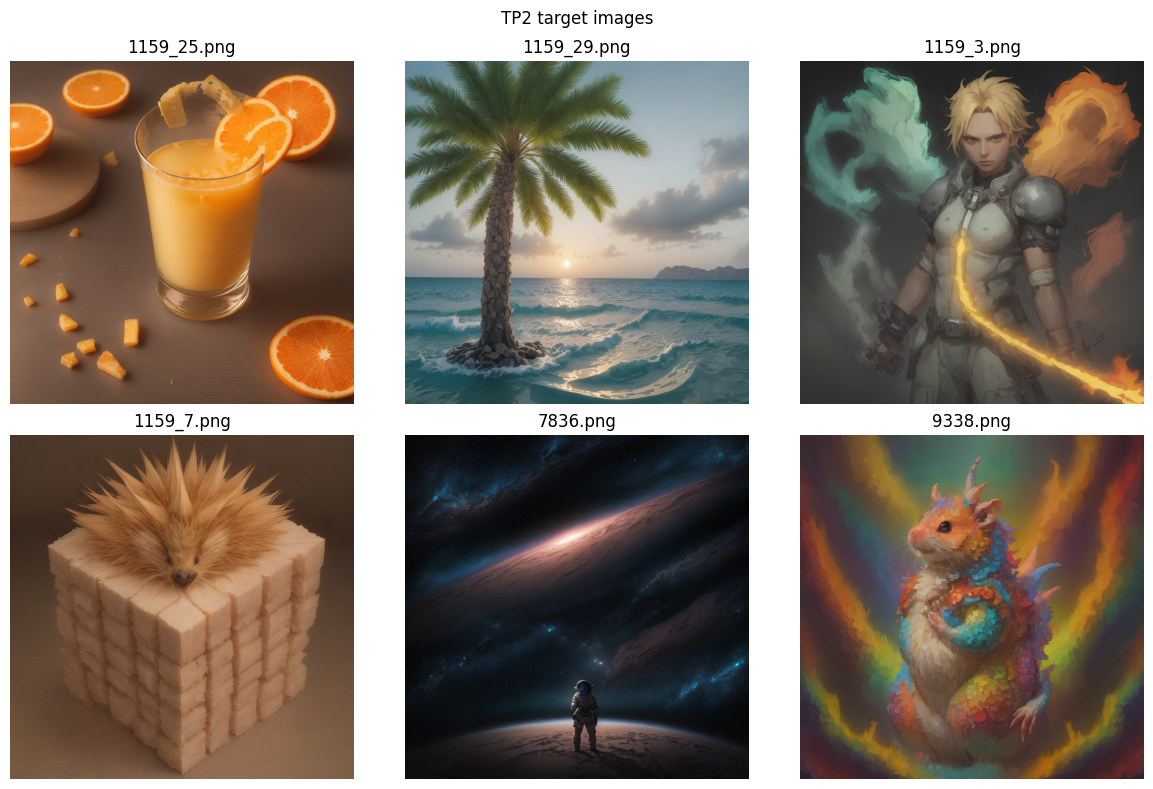

In [4]:
show_images(target_images, cols=3, title="TP2 target images")


## 4. Load the LCM Generator

These are the fixed generation settings used for TP2 targets.

In [5]:
from dataclasses import dataclass
import torch
from diffusers import DiffusionPipeline, LCMScheduler


@dataclass(frozen=True)
class LCMConfig:
    model_id: str = "SimianLuo/LCM_Dreamshaper_v7"
    seed: int = 2026  # fallback only; target filenames define the real render seed
    num_inference_steps: int = 8
    guidance_scale: float = 8.0
    lcm_origin_steps: int = 50
    width: int = 768
    height: int = 768


config = LCMConfig()


def default_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


device = default_device()
print("Using device:", device)


def load_lcm_pipeline(config):
    dtype = torch.float32
    pipe = DiffusionPipeline.from_pretrained(
        config.model_id,
        torch_dtype=dtype,
        use_safetensors=True,
    )
    pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)
    if hasattr(pipe, "safety_checker"):
        pipe.safety_checker = None
    pipe.to(device)
    return pipe


pipe = load_lcm_pipeline(config)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

## 5. Generate and Save Images

Use `render_prompt_for_target(...)` to render a prompt with the seed encoded in the target filename.

In [6]:
import numpy as np
from PIL import Image

def _normalize_generated_image(image_array):
    image_array = np.asarray(image_array, dtype=np.float32)
    image_array = np.nan_to_num(image_array, nan=0.0, posinf=1.0, neginf=0.0)
    min_value = float(image_array.min()) if image_array.size else 0.0
    max_value = float(image_array.max()) if image_array.size else 0.0
    if min_value < 0.0 or max_value > 1.0:
        if min_value >= -1.0 and max_value <= 1.0:
            image_array = (image_array + 1.0) / 2.0
        else:
            spread = max_value - min_value
            if spread > 1e-8:
                image_array = (image_array - min_value) / spread
            else:
                image_array = np.zeros_like(image_array)
    image_array = np.clip(image_array, 0.0, 1.0)
    return image_array, min_value, max_value

def render_prompt(prompt, seed, pipe=pipe, config=config):
    generator_device = "cpu" if device == "mps" else device
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    result = pipe(
        prompt=prompt,
        num_inference_steps=config.num_inference_steps,
        guidance_scale=config.guidance_scale,
        lcm_origin_steps=config.lcm_origin_steps,
        width=config.width,
        height=config.height,
        output_type="np",
        generator=generator,
    )
    raw_image = result.images[0]
    print("generated raw type:", type(raw_image), "dtype:", getattr(raw_image, "dtype", None), "shape:", getattr(raw_image, "shape", None))
    image_array, min_value, max_value = _normalize_generated_image(raw_image)
    nonzero_count = int(np.count_nonzero(image_array))
    mean_value = float(image_array.mean()) if image_array.size else 0.0
    print(f"generated image range: min={min_value:.8e}, max={max_value:.8e}, mean={mean_value:.8e}, nonzero={nonzero_count}")
    image_array = (image_array * 255.0).round().astype(np.uint8)
    return Image.fromarray(image_array)


def render_prompt_for_target(prompt, target_path):
    seed = seed_from_filename(target_path, config.seed)
    return render_prompt(prompt, seed=seed)


def save_generated_image(image, run_dir, target_path, prompt_index=1):
    target_dir = Path(run_dir) / safe_stem(target_path)
    target_dir.mkdir(parents=True, exist_ok=True)
    path = target_dir / f"candidate_{prompt_index:03d}.png"
    image.save(path)
    return path


## 6. Implementation

### Vision-language captioning + prompt retrieval + LLM-based refinement

#### Vision-language captioning using BLIP and CLIP + prompt retrieval:
1. Use BLIP to generate a small initial set of captions for each target image.
2. Use CLIP to retrieve the best-matching prompts from that corpus.
3. Render the retrieved prompts with LCM and rerank by image similarity to the target.

### LLM-based refinement:
4. Iteratively edit the prompt with an LLM using image-side feedback as the signal.

## BLIP
#### Converts image to text by generating a natural descriptions of the image.

In [7]:
# Generate x captions per image using BLIP
from transformers import BlipProcessor, BlipForConditionalGeneration

BLIP_MODEL = "Salesforce/blip-image-captioning-large"

processor = BlipProcessor.from_pretrained(BLIP_MODEL, use_fast=False)
model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL).to("cuda")
print("Loaded BLIP model for captioning:", BLIP_MODEL, "on device:", device)

def generate_captions_for_image(target_path, num_captions=None, device=device, max_length=75, temperature=0.9, top_k=50, top_p=0.95):
    """Return a list of textual captions for the input image using BLIP."""
    image = load_image(target_path)
    inputs = processor(images=image, return_tensors="pt").to(device)

    # do_sample=True enables sampling-based generation, which allows for more diverse captions compared to greedy decoding.
    # top_k is the number of highest-probability vocabulary tokens to keep for top-k-filtering
    # top_p is the cumulative probability for nucleus sampling; tokens are sorted by probability and added until the sum of probabilities exceeds top_p
    # temperature controls randomness in sampling: higher values lead to more random outputs, while lower values make the model more deterministic.
    # num_return_sequences is the number of captions to generate for the same image, which can be useful for diversity.
    # max_length limits the length of the generated captions to prevent excessively long outputs.
    outputs = model.generate(
        **inputs,
        do_sample=True,
        top_k=top_k,
        top_p=top_p,
        temperature=temperature,
        num_return_sequences=num_captions,
        max_length=max_length,
    )

    tokenizer = processor.tokenizer
    captions = [tokenizer.decode(o, skip_special_tokens=True).strip() for o in outputs]
    return captions

print("Generated captions for target images:")
captions_by_target = {}
for target_path in target_images:
    target_captions = generate_captions_for_image(target_path, num_captions=100)
    captions_by_target[Path(target_path).name] = target_captions
    print(f"{Path(target_path).name} original captions:")
    for caption in target_captions:
         print("  -", caption)

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

Loaded BLIP model for captioning: Salesforce/blip-image-captioning-large on device: cuda
Generated captions for target images:
1159_25.png original captions:
  - bright orange juice is blended into a glass with a small amount of cubes of sugar
  - ##ng glass of orange juice with some cut orange slices and pieces of crumbles around it
  - an orange juice with a splash of sugar cubes and orange slices on a board
  - there are oranges and milk in this cup on a grey surface
  - blood orange drink with a spoon sticking out of the glass with orange slices surrounding it
  - peeled oranges sitting on a table next to a tall glass of juice
  - there is a glass full of orange juice and pieces of oranges
  - they are all oranges cut up and laying on a table
  - a heavily orange juice in a tall glass surrounded by pieces of croute on top
  - wrinkled oranges and a glass of juice are scattered on a grey surface
  - a located picture of some oranges, some slices and a glass of orange juice
  - orang

## CLIP embed and rerank + Prompt retrieval

### A prompt corpus is searched by CLIP image embedding, then re-ranked by LCM-rendered similarity.

In [ ]:
import re

import torch
import torch.nn.functional as F
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

CLIP_MODEL_ID = "openai/clip-vit-large-patch14"
CLIP_RETRIEVAL_TOP_K = 100 # this is the number of top candidates to retrieve based on CLIP text-image similarity before reranking by rendered similarity
CLIP_RERANK_TOP_K = 20 # this is the number of candidates to rerank based on rendered similarity; should be <= CLIP_RETRIEVAL_TOP_K

_clip_bundle = None


def normalize_prompt_text(text):
    """Normalize prompt text by stripping whitespace,
    collapsing multiple spaces,
    and removing common punctuation from the ends."""
    text = str(text or "").strip()
    text = re.sub(r"\s+", " ", text)
    text = text.strip(" \t\n\r,.;:")
    return text


def build_prompt_corpus(captions):
    """Build a unique corpus of cleaned captions,
    preserving order but removing duplicates and empty entries."""
    corpus = []
    seen = set()
    for caption in captions:
        cleaned = normalize_prompt_text(caption)
        if not cleaned or cleaned in seen:
            continue
        seen.add(cleaned)
        corpus.append(cleaned)
    return corpus


def _get_clip_bundle(model_name=CLIP_MODEL_ID):
    """Load and cache the CLIP model and processor
    for the given model name."""
    global _clip_bundle
    if _clip_bundle is not None and _clip_bundle["model_name"] == model_name:
        return _clip_bundle

    processor = CLIPProcessor.from_pretrained(model_name)
    model = CLIPModel.from_pretrained(model_name, use_safetensors=True)
    model = model.to(device)
    model.eval()
    _clip_bundle = {
        "model_name": model_name,
        "processor": processor,
        "model": model,
    }
    print("CLIP model:",{model_name},"was loaded into device",{device})
    return _clip_bundle


@torch.inference_mode()
def encode_clip_texts(texts, model_name=CLIP_MODEL_ID, batch_size=32):
    """Encode a list of texts into CLIP text embeddings,
    returning the embeddings and the cleaned texts.
    Inputs: - texts: list of strings to encode
            - model_name: which CLIP model to use
            - batch_size: how many texts to encode at once (for memory efficiency)
    Outputs: - embeddings: tensor of shape (num_texts, embedding_dim) with normalized CLIP text embeddings
             - cleaned_texts: list of cleaned texts corresponding to the embeddings"""
    bundle = _get_clip_bundle(model_name)
    processor = bundle["processor"]
    model = bundle["model"]

    cleaned_texts = [normalize_prompt_text(text) for text in texts]
    cleaned_texts = [text for text in cleaned_texts if text]
    if not cleaned_texts:
        raise ValueError("No valid texts were provided for CLIP encoding.")

    # an embedding is a vector representation of text in a high-dimensional space, where semantically similar texts are mapped to nearby points.
    embeddings = []
    for start in range(0, len(cleaned_texts), batch_size):
        batch_texts = cleaned_texts[start:start + batch_size]
        inputs = processor(text=batch_texts, return_tensors="pt", padding=True, truncation=True)
        inputs = {key: value.to(device) for key, value in inputs.items()}
        features = model.get_text_features(**inputs)
        features = F.normalize(features, dim=-1)
        embeddings.append(features.detach().cpu())

    return torch.cat(embeddings, dim=0), cleaned_texts


@torch.inference_mode()
def encode_clip_image(image, model_name=CLIP_MODEL_ID):
    """Encode an image into a CLIP image embedding.
    Inputs: - image: a PIL Image or a path to an image file
            - model_name: which CLIP model to use
    Output: - embedding: tensor of shape (embedding_dim,) with the normalized CLIP image embedding"""
    bundle = _get_clip_bundle(model_name)
    processor = bundle["processor"]
    model = bundle["model"]

    if not isinstance(image, Image.Image):
        image = load_image(image)

    inputs = processor(images=image, return_tensors="pt")
    inputs = {key: value.to(device) for key, value in inputs.items()}
    features = model.get_image_features(**inputs)
    features = F.normalize(features, dim=-1)
    return features.detach().cpu()[0]


def retrieve_prompts_by_clip(target_path, prompt_corpus, top_k=CLIP_RETRIEVAL_TOP_K, model_name=CLIP_MODEL_ID, batch_size=32):
    """Retrieve the top-k prompts from the corpus that are most similar to the target image according to CLIP text-image similarity.
    Inputs: - target_path: path to the target image file
            - prompt_corpus: list of candidate prompt strings to compare against
            - top_k: how many top candidates to return
            - model_name: which CLIP model to use for encoding
            - batch_size: how many prompts to encode at once (for memory efficiency)
    Output: - ranked: list of dicts with keys 'rank', 'prompt', 'clip_text_score', and 'prompt_index', sorted by descending CLIP similarity score"""
    prompt_embeddings, cleaned_prompts = encode_clip_texts(prompt_corpus, model_name=model_name, batch_size=batch_size)
    target_image = load_image(target_path)
    target_embedding = encode_clip_image(target_image, model_name=model_name)

    scores = torch.matmul(prompt_embeddings, target_embedding)
    top_k = min(int(top_k), len(cleaned_prompts))
    if top_k <= 0:
        return []

    top_scores, top_indices = torch.topk(scores, k=top_k)
    ranked = []
    for rank, (score, index) in enumerate(zip(top_scores.tolist(), top_indices.tolist()), start=1):
        ranked.append({
            "rank": rank,
            "prompt": cleaned_prompts[index],
            "clip_text_score": float(score),
            "prompt_index": int(index),
        })
    return ranked


@torch.inference_mode()
def rerank_prompts_by_rendered_similarity(target_path, ranked_prompts, rerank_k=CLIP_RERANK_TOP_K, run_dir=None, model_name=CLIP_MODEL_ID, config=None):
    """Rerank the top-k prompts based on the similarity between the target image and the images rendered from the prompts.
    Inputs: - target_path: path to the target image file
            - ranked_prompts: list of dicts with keys 'prompt' and optionally 'clip_text_score' from the previous CLIP retrieval step
            - rerank_k: how many top candidates to rerank based on rendered similarity (should be <= len(ranked_prompts))
            - run_dir: optional directory to save the rendered images for inspection; if None, images won't be saved
            - model_name: which CLIP model to use for encoding the rendered images
            - config: optional LCMConfig to use for rendering; if None, will look for a global 'config' variable
    Output: - reranked: list of dicts with keys 'prompt', 'clip_text_score', 'rendered_clip_score', and optionally
    'render' (path to saved rendered image), sorted by descending rendered CLIP similarity score, and with an added
    'rerank' key indicating the new rank after reranking"""
    render_config = config if config is not None else globals().get("config")
    if render_config is None:
        raise ValueError("Render config is not available. Run the LCM config cell first.")

    target_image = load_image(target_path)
    target_embedding = encode_clip_image(target_image, model_name=model_name)
    seed = seed_from_filename(target_path, render_config.seed)

    rerank_k = min(int(rerank_k), len(ranked_prompts))
    if rerank_k <= 0:
        return []

    rows = []
    for item in ranked_prompts[:rerank_k]:
        prompt = item["prompt"] if isinstance(item, dict) else str(item)
        generated_image = render_prompt(prompt, seed=seed, config=render_config)
        generated_embedding = encode_clip_image(generated_image, model_name=model_name)
        rendered_similarity = float(torch.dot(target_embedding, generated_embedding).item())

        row = {
            "prompt": prompt,
            "clip_text_score": float(item.get("clip_text_score", float("nan"))) if isinstance(item, dict) else float("nan"),
            "rendered_clip_score": rendered_similarity,
        }

        if run_dir is not None:
            image_path = save_generated_image(generated_image, run_dir, target_path, prompt_index=len(rows) + 1)
            row["render"] = str(image_path)

        rows.append(row)

    rows.sort(key=lambda row: row["rendered_clip_score"], reverse=True)
    for index, row in enumerate(rows, start=1):
        row["rerank"] = index
    return rows


def retrieve_and_rerank_prompts(target_path, prompt_corpus, retrieval_k=CLIP_RETRIEVAL_TOP_K, rerank_k=CLIP_RERANK_TOP_K, run_dir=None, model_name=CLIP_MODEL_ID, config=None):
    """Convenience function to perform both CLIP retrieval and rendered similarity reranking in one step.
    Inputs: - target_path: path to the target image file
            - prompt_corpus: list of candidate prompt strings to compare against
            - retrieval_k: how many top candidates to retrieve based on CLIP text-image similarity before reranking
            - rerank_k: how many top candidates to rerank based on rendered similarity (should be <= retrieval_k)
            - run_dir: optional directory to save the rendered images for inspection; if None, images won't be saved
            - model_name: which CLIP model to use for encoding
            - config: optional LCMConfig to use for rendering; if None, will look for a global 'config' variable
    Output: - retrieved: list of dicts from the CLIP retrieval step
            - reranked: list of dicts from the rendered similarity reranking step, with added 'rerank' keys indicating the new rank after reranking"""
    retrieved = retrieve_prompts_by_clip(
        target_path=target_path,
        prompt_corpus=prompt_corpus,
        top_k=retrieval_k,
        model_name=model_name,
    )
    reranked = rerank_prompts_by_rendered_similarity(
        target_path=target_path,
        ranked_prompts=retrieved,
        rerank_k=rerank_k,
        run_dir=run_dir,
        model_name=model_name,
        config=config,
    )
    return retrieved, reranked

In [ ]:
# ONLY RUN ON COLAB
# MUST RUN ON COLAB
# FIX: Re-define CLIP encoding functions to handle both old and new transformers versions.
# In newer versions of the transformers library (installed in Colab), model.get_image_features()
# and model.get_text_features() may return a BaseModelOutputWithPooling object instead of
# a plain tensor. We extract the tensor explicitly before normalizing.

@torch.inference_mode()
def encode_clip_texts(texts, model_name=CLIP_MODEL_ID, batch_size=32):
    """Encode a list of texts into normalized CLIP text embeddings."""
    bundle = _get_clip_bundle(model_name)
    processor = bundle["processor"]
    model = bundle["model"]

    cleaned_texts = [normalize_prompt_text(text) for text in texts]
    cleaned_texts = [text for text in cleaned_texts if text]
    if not cleaned_texts:
        raise ValueError("No valid texts were provided for CLIP encoding.")

    embeddings = []
    for start in range(0, len(cleaned_texts), batch_size):
        batch_texts = cleaned_texts[start:start + batch_size]
        inputs = processor(text=batch_texts, return_tensors="pt", padding=True, truncation=True)
        inputs = {key: value.to(device) for key, value in inputs.items()}
        features = model.get_text_features(**inputs)
        # FIX: extract tensor if the model returned a dataclass object
        if not isinstance(features, torch.Tensor):
            features = features.pooler_output if hasattr(features, "pooler_output") else features.last_hidden_state[:, 0]
        features = F.normalize(features, dim=-1)
        embeddings.append(features.detach().cpu())

    return torch.cat(embeddings, dim=0), cleaned_texts


@torch.inference_mode()
def encode_clip_image(image, model_name=CLIP_MODEL_ID):
    """Encode an image into a normalized CLIP image embedding."""
    bundle = _get_clip_bundle(model_name)
    processor = bundle["processor"]
    model = bundle["model"]

    if not isinstance(image, Image.Image):
        image = load_image(image)

    inputs = processor(images=image, return_tensors="pt")
    inputs = {key: value.to(device) for key, value in inputs.items()}
    features = model.get_image_features(**inputs)
    # FIX: extract tensor if the model returned a dataclass object
    if not isinstance(features, torch.Tensor):
        features = features.pooler_output if hasattr(features, "pooler_output") else features.last_hidden_state[:, 0]
    features = F.normalize(features, dim=-1)
    return features.detach().cpu()[0]

print("CLIP encoding functions patched for compatibility with newer transformers versions.")


CLIP encoding functions patched for compatibility with newer transformers versions.


In [10]:
# Prompt corpus is searched by CLIP image embedding
# All target images - CLIP Retrieval
if "captions_by_target" in globals() and target_images:
    # Dictionary to store retrieved prompts for each target image (can be useful for downstream cells)
    all_retrieved_prompts = {}

    print(f"Starting CLIP retrieval for all {len(target_images)} target images...\n")

    for target_path in target_images:
        target_key = Path(target_path).name
        target_captions = captions_by_target.get(target_key, [])
        prompt_corpus = build_prompt_corpus(target_captions)

        print(f"CLIP prompt corpus ready for {target_key}: {len(prompt_corpus)} prompt(s)")

        if prompt_corpus:
            # Retrieve the top k prompts for this target image
            retrieved_prompts = retrieve_prompts_by_clip(target_path, prompt_corpus, top_k=CLIP_RETRIEVAL_TOP_K)
            all_retrieved_prompts[target_key] = retrieved_prompts

            print(f"Top CLIP retrieval candidates for {target_key}:")
            for item in retrieved_prompts[:3]:
                print(f"  {item['rank']:02d}. {item['prompt']}  (score={item['clip_text_score']:.4f})")
        else:
            print(f"  No prompts available in corpus for {target_key}")

        print("-" * 60)

    # Expose the top-1 retrieved prompts list as 'retrieved_prompts' for compatibility with downstream cells
    # (defaults to the first target image's retrieved prompts)
    if target_images:
        first_key = Path(target_images[0]).name
        retrieved_prompts = all_retrieved_prompts.get(first_key, [])
else:
    print("CLIP retrieval helpers loaded. Define target captions first, then call build_prompt_corpus(example_captions).")

Starting CLIP retrieval for all 6 target images...

CLIP prompt corpus ready for 1159_25.png: 100 prompt(s)


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIP model: {'openai/clip-vit-large-patch14'} was loaded into device {'cuda'}
Top CLIP retrieval candidates for 1159_25.png:
  01. ##ng glass of orange juice with some cut orange slices and pieces of crumbles around it  (score=0.3252)
  02. an orange juice in a glass with orange pieces on a table  (score=0.3166)
  03. ##ng an orange juice in a glass next to some oranges  (score=0.3083)
------------------------------------------------------------
CLIP prompt corpus ready for 1159_29.png: 100 prompt(s)
Top CLIP retrieval candidates for 1159_29.png:
  01. artist - rendering of a palm tree in the ocean with the sun setting  (score=0.3306)
  02. digitally rendering of a palm tree near the ocean on a rocky island  (score=0.3287)
  03. rendering of a palm tree standing in the waves at the beach  (score=0.3277)
------------------------------------------------------------
CLIP prompt corpus ready for 1159_3.png: 100 prompt(s)
Top CLIP retrieval candidates for 1159_3.png:
  01. blonde haired fem

In [11]:
# Prompt corpus is searched by CLIP image embedding, then re-ranked by LCM-rendered similarity.
# All target images — CLIP Retrieval + LCM-Rendered Reranking:
if "captions_by_target" in globals() and target_images:
    all_retrieved_prompts = {}   # Phase 1 results: CLIP text retrieval
    all_reranked_prompts = {}    # Phase 2 results: LCM-rendered reranking

    print(f"Starting CLIP Retrieval + Rendered Reranking for all {len(target_images)} target images...\n")

    for target_path in target_images:
        target_key = Path(target_path).name
        target_captions = captions_by_target.get(target_key, [])
        prompt_corpus = build_prompt_corpus(target_captions)

        print("=" * 60)
        print(f"TARGET: {target_key} — corpus: {len(prompt_corpus)} prompt(s)")
        print("=" * 60)

        if not prompt_corpus:
            print("  No prompts available in corpus.")
            print()
            continue

        # --- Phase 1: CLIP Text-Image Retrieval ---
        retrieved_prompts = retrieve_prompts_by_clip(target_path, prompt_corpus, top_k=CLIP_RETRIEVAL_TOP_K)
        all_retrieved_prompts[target_key] = retrieved_prompts

        print("Phase 1 — Top CLIP Text Retrieval candidates (text ↔ image similarity):")
        for item in retrieved_prompts[:3]:
            print(f"  {item['rank']:02d}. {item['prompt']}  (clip_text_score={item['clip_text_score']:.4f})")

        # --- Phase 2: LCM-Rendered Image Reranking ---
        # Rerank among the top k CLIP text candidates by rendering them and
        # comparing the rendered image directly to the target image (image ↔ image similarity)
        print("\nPhase 2 — Reranking by LCM-Rendered Similarity (rendered image ↔ target image)...")
        _, reranked_prompts = retrieve_and_rerank_prompts(
            target_path=target_path,
            prompt_corpus=prompt_corpus,
            retrieval_k=CLIP_RETRIEVAL_TOP_K,   # from top-k CLIP text candidates...
            rerank_k=CLIP_RERANK_TOP_K,      # ...rerank k by rendering
            run_dir=None,
        )
        all_reranked_prompts[target_key] = reranked_prompts

        print("Phase 2 — Top Reranked candidates (after rendering):")
        for item in reranked_prompts[:3]:
            print(f"  {item['rerank']:02d}. {item['prompt']}  (rendered_clip_score={item['rendered_clip_score']:.4f}  |  text_score={item['clip_text_score']:.4f})")

        # Show if the top candidate changed between Phase 1 and Phase 2
        if retrieved_prompts and reranked_prompts:
            top1_text = retrieved_prompts[0]["prompt"]
            top1_rendered = reranked_prompts[0]["prompt"]
            if top1_text != top1_rendered:
                print(f"\n  ⚠ Top prompt changed after reranking!")
                print(f"    Before: '{top1_text}'")
                print(f"    After:  '{top1_rendered}'")
            else:
                print(f"\n  ✓ Top prompt unchanged after reranking.")

        print()

    # Keep compatibility with downstream cells
    if target_images:
        first_key = Path(target_images[0]).name
        retrieved_prompts = all_retrieved_prompts.get(first_key, [])
        reranked_prompts = all_reranked_prompts.get(first_key, [])
else:
    print("CLIP retrieval helpers loaded. Define target captions first, then call build_prompt_corpus(example_captions).")


Starting CLIP Retrieval + Rendered Reranking for all 6 target images...

TARGET: 1159_25.png — corpus: 100 prompt(s)
Phase 1 — Top CLIP Text Retrieval candidates (text ↔ image similarity):
  01. ##ng glass of orange juice with some cut orange slices and pieces of crumbles around it  (clip_text_score=0.3252)
  02. an orange juice in a glass with orange pieces on a table  (clip_text_score=0.3166)
  03. ##ng an orange juice in a glass next to some oranges  (clip_text_score=0.3083)

Phase 2 — Reranking by LCM-Rendered Similarity (rendered image ↔ target image)...


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=4.15723622e-01, nonzero=1768114


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=3.38231504e-01, nonzero=1763094


...

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=4.44414914e-02, max=9.42660511e-01, mean=3.36401343e-01, nonzero=1769472


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=6.12543225e-02, max=9.92028594e-01, mean=4.92441863e-01, nonzero=1769472


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=4.53823507e-02, max=9.80328560e-01, mean=4.27988976e-01, nonzero=1769472
Phase 2 — Top Reranked candidates (after rendering):
  01. painting of a colorful rat with colorful hair and colorful wings  (rendered_clip_score=0.8067  |  text_score=0.3125)
  02. rainbow colored painting of a large furry rat holding a colorful rock  (rendered_clip_score=0.8002  |  text_score=0.3135)
  03. painting of a mouse in art with a rainbow - lit background  (rendered_clip_score=0.7887  |  text_score=0.2963)

  ⚠ Top prompt changed after reranking!
    Before: 'illustration painting of a mouse with a rainbow dragon tail on its back'
    After:  'painting of a colorful rat with colorful hair and colorful wings'



In [12]:
# Show the results of all renderings
if "all_reranked_prompts" in globals() and all_reranked_prompts:
    print(f"=== RERANKING RESULTS  ({len(all_reranked_prompts)} TARGET IMAGES) ===\n")

    for target_key, prompts_list in all_reranked_prompts.items():
        print("=" * 90)
        print(f" TARGET: {target_key}")
        print("=" * 90)

        # Ensure sorting by the rendered image score (from highest to lowest)
        sorted_prompts = sorted(prompts_list, key=lambda x: x.get("rendered_clip_score", 0), reverse=True)

        for idx, item in enumerate(sorted_prompts, 1):
            prompt = item.get("prompt", "")
            rendered_score = item.get("rendered_clip_score", 0.0)
            text_score = item.get("clip_text_score", 0.0)

            # Format the print statement
            print(f" Pos {idx:02d} | Visual Score (Rendered): {rendered_score:.4f} | Text Score (CLIP): {text_score:.4f}")
            print(f"        Prompt: \"{prompt}\"")
            print("-" * 90)
        print("\n" * 2)
else:
    print("The variable 'all_reranked_prompts' was not found in memory or is empty.")
    print("Make sure the reranking cell has finished running before executing this cell.")


=== RERANKING RESULTS  (6 TARGET IMAGES) ===

 TARGET: 1159_25.png
 Pos 01 | Visual Score (Rendered): 0.9398 | Text Score (CLIP): 0.3166
        Prompt: "an orange juice in a glass with orange pieces on a table"
------------------------------------------------------------------------------------------
 Pos 02 | Visual Score (Rendered): 0.9372 | Text Score (CLIP): 0.3004
        Prompt: "the orange slices and pieces of bread are falling into the glass of orange juice"
------------------------------------------------------------------------------------------
 Pos 03 | Visual Score (Rendered): 0.9351 | Text Score (CLIP): 0.3039
        Prompt: "brightly lit orange juice with fresh slices of fruit surrounding"
------------------------------------------------------------------------------------------
 Pos 04 | Visual Score (Rendered): 0.9336 | Text Score (CLIP): 0.3252
        Prompt: "##ng glass of orange juice with some cut orange slices and pieces of crumbles around it"
-----------------

## LLM-based refinement

### Prompt is iteratively edited with an LLM using image-side feedback as the signal.

In [39]:
import uuid
import time
import json
import os
import urllib.request
import numpy as np
import torch
import lpips
import torch.nn.functional as F
from PIL import Image
from pathlib import Path

IAEDU_API_URL = globals().get("IAEDU_API_URL") or os.getenv("IAEDU_API_URL", "https://example")
IAEDU_API_KEY = "example"
IAEDU_CHANNEL_ID = globals().get("IAEDU_CHANNEL_ID") or os.getenv("IAEDU_CHANNEL_ID", "example")

def _image_to_array(image, size=None):
    if not isinstance(image, Image.Image):
        image = load_image(image)
    if size is not None:
        image = image.resize(size, Image.Resampling.LANCZOS)
    return np.asarray(image.convert("RGB"), dtype=np.float32) / 255.0

# Global variable to cache the LPIPS model and avoid reloading it
_lpips_loss_fn = None

def get_lpips_model(net='vgg', device=None):
    """Initialize and load the LPIPS model once (lazy loading)."""
    global _lpips_loss_fn
    if _lpips_loss_fn is None:
        target_device = device if device is not None else globals().get("device", "cuda" if torch.cuda.is_available() else "cpu")
        print(f"Loading LPIPS model (net: {net}) on device: {target_device}...")
        # LPIPS will download VGG weights on the first run
        _lpips_loss_fn = lpips.LPIPS(net=net).to(target_device)
        _lpips_loss_fn.eval()
    return _lpips_loss_fn

def lpips_between_images(target_image, generated_image, device=None):
    # LPIPS expects normalized tensors in the [-1, 1] range, with shape [1, C, H, W]
    def to_lpips_tensor(img):
        arr = np.array(img).astype(np.float32) / 255.0 # Scale to [0, 1]
        arr = arr * 2.0 - 1.0 # Scale to [-1, 1]
        tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0) # [1, C, H, W]
        target_device = device if device is not None else globals().get("device", "cuda" if torch.cuda.is_available() else "cpu")
        return tensor.to(target_device)

    t_a = to_lpips_tensor(target_image)
    t_b = to_lpips_tensor(generated_image)

    loss_fn = get_lpips_model(device=device)

    with torch.no_grad():
        dist = loss_fn(t_a, t_b)

    return float(dist.item())

def mse_between_images(target_image, generated_image, size=None):
    target_array = _image_to_array(target_image, size=size)
    generated_array = _image_to_array(generated_image, size=size)
    return float(np.mean((target_array - generated_array) ** 2))

def clip_image_similarity(target_image, generated_image, model_name=CLIP_MODEL_ID):
    target_embedding = encode_clip_image(target_image, model_name=model_name)
    generated_embedding = encode_clip_image(generated_image, model_name=model_name)
    return float(torch.dot(target_embedding, generated_embedding).item())

def score_prompt_against_target(target_path, prompt, seed=None, render_config=None, model_name=CLIP_MODEL_ID):
    render_config = render_config if render_config is not None else globals().get("config")
    if render_config is None:
        raise ValueError("Render config is not available.")
    seed = seed if seed is not None else seed_from_filename(target_path, render_config.seed)
    target_image = load_image(target_path)
    generated_image = render_prompt(prompt, seed=seed, config=render_config)
    metrics = {
        "clip_similarity": clip_image_similarity(target_image, generated_image, model_name=model_name),
        "mse": mse_between_images(target_image, generated_image, size=(256, 256)),
        "lpips": lpips_between_images(target_image, generated_image, device=device),
    }
    return generated_image, metrics

def _encode_multipart_formdata(fields, files=None, boundary=None):
    boundary = boundary or f"----tp2boundary{os.urandom(8).hex()}"
    body = bytearray()
    crlf = b"\r\n"

    def append_line(text):
        body.extend(text.encode("utf-8"))
        body.extend(crlf)

    for name, value in fields.items():
        append_line(f"--{boundary}")
        append_line(f"Content-Disposition: form-data; name=\"{name}\"")
        body.extend(crlf)
        body.extend(str(value).encode("utf-8"))
        body.extend(crlf)

    for name, file_info in (files or {}).items():
        filename, content, content_type = file_info
        append_line(f"--{boundary}")
        append_line(f"Content-Disposition: form-data; name=\"{name}\"; filename=\"{filename}\"")
        append_line(f"Content-Type: {content_type}")
        body.extend(crlf)
        body.extend(content if isinstance(content, (bytes, bytearray)) else str(content).encode("utf-8"))
        body.extend(crlf)

    append_line(f"--{boundary}--")
    body.extend(crlf)
    return bytes(body), boundary

def _post_iaedu_stream(url, api_key, channel_id, message, thread_id="", user_info=None, user_id=None, user_context=None, image_path=None):
    fields = {
        "channel_id": channel_id,
        "thread_id": thread_id or "",
        "user_info": json.dumps(user_info or {}, ensure_ascii=False),
        "message": message,
    }
    if user_id is not None:
        fields["user_id"] = user_id
    if user_context is not None:
        fields["user_context"] = json.dumps(user_context, ensure_ascii=False)
    files = {}
    if image_path is not None:
        image_path = Path(image_path)
        image_bytes = image_path.read_bytes()
        files["image"] = (image_path.name, image_bytes, "image/png" if image_path.suffix.lower() == ".png" else "application/octet-stream")
    body, boundary = _encode_multipart_formdata(fields, files=files)
    request = urllib.request.Request(
        url,
        data=body,
        headers={
            "Content-Type": f"multipart/form-data; boundary={boundary}",
            "x-api-key": api_key,
            "Accept": "text/event-stream",
        },
        method="POST",
    )
    with urllib.request.urlopen(request, timeout=120) as response:
        raw_text = response.read().decode("utf-8", errors="replace")
    if raw_text.startswith("data:"):
        raw_text = raw_text.split("data:", 1)[-1].strip()
    return raw_text

def refine_prompt_with_llm(current_prompt, target_name, captions, metrics, iteration, history):
   user_prompt = (
       f"Target image: {target_name}\n"
       f"Current prompt: {current_prompt}\n"
       f"Captions: {', '.join(captions) if captions else 'none'}\n"
       f"Metrics: CLIP={metrics.get('clip_similarity'):.4f}, MSE={metrics.get('mse'):.6f}, LPIPS={metrics.get('lpips'):.4f}\n"
       f"Iteration: {iteration}\n"
       f"Recent history: {json.dumps(history[-3:], ensure_ascii=False)}\n"
       "Improve the prompt using the image-side feedback. Return only JSON with keys prompt and notes."
   )
   content = None  # <-- FIX: always define content first
   try:
       if IAEDU_API_URL and IAEDU_API_KEY and IAEDU_CHANNEL_ID:
           # Generate a fresh unique thread_id per call to avoid context_limit
           fresh_thread_id = str(uuid.uuid4()).replace("-", "")[:24]
           content = _post_iaedu_stream(
               IAEDU_API_URL,
               IAEDU_API_KEY,
               IAEDU_CHANNEL_ID,
               message=user_prompt,
               thread_id=fresh_thread_id,
               user_info={},
           )
   except Exception as e:
       print(f"  [WARNING] LLM API call failed: {e}")
       return current_prompt, f"API error: {e}"
   if not content:
       print("  [WARNING] LLM returned empty response.")
       return current_prompt, "empty response"
   print(f"  [DEBUG] Raw LLM response (Full): {repr(content)}")
   data = _extract_json_payload(content)
   print(f"  [DEBUG] Parsed JSON data: {data}")
   refined_prompt = normalize_prompt_text(data.get("prompt", "")) or current_prompt
   notes = str(data.get("notes", "")).strip()
   return refined_prompt, notes

def _extract_json_payload(content):
    if not isinstance(content, str):
        return content
    text = content.strip()

    # Process SSE/Event-Stream newline-delimited JSON formats first if present
    lines = [line.strip() for line in text.splitlines() if line.strip()]

    # Try to accumulate streamed tokens if they are present in SSE style
    token_parts = []
    has_tokens = False
    for line in lines:
        temp_line = line
        if temp_line.startswith("data:"):
            temp_line = temp_line[len("data:"):].strip()
        if not temp_line:
            continue
        try:
            obj = json.loads(temp_line)
            if isinstance(obj, dict) and obj.get("type") == "token":
                token_parts.append(obj.get("content", ""))
                has_tokens = True
        except:
            pass

    # If we successfully accumulated tokens, reconstruct the full text
    if has_tokens:
        text = "".join(token_parts).strip()
    else:
        # Check for standard "message" event format inside the lines
        for line in lines:
            if line.startswith("data:"):
                line = line[len("data:"):].strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                if isinstance(obj, dict) and obj.get("type") == "message":
                    msg_content = obj.get("content")
                    if isinstance(msg_content, dict):
                        inner_text = msg_content.get("content", "")
                        if isinstance(inner_text, str):
                            res = _extract_json_payload(inner_text)
                            if isinstance(res, dict) and (res.get("prompt") or res.get("notes")):
                                return res
            except:
                pass

    # Handle markdown codeblock wrapper if present
    if text.startswith("```"):
        parts = text.split("```")
        if len(parts) >= 3:
            candidate = parts[1] if len(parts[1].strip()) >= len(parts[2].strip()) else parts[2]
            candidate_lines = candidate.splitlines()
            if candidate_lines and candidate_lines[0].strip().lower() in {"json", "javascript", "python"}:
                candidate_lines = candidate_lines[1:]
            text = "\n".join(candidate_lines).strip()

    first = text.find("{")
    if first != -1:
        decoder = json.JSONDecoder()
        try:
            payload, _ = decoder.raw_decode(text[first:])
            return payload
        except json.JSONDecodeError:
            pass

    # Try regex extraction if raw decode fails due to truncated/incomplete JSON
    try:
        import re
        prompt_match = re.search(r'"prompt"\s*:\s*"([^"\\]*(?:\\.[^"\\]*)*)"', text)
        notes_match = re.search(r'"notes"\s*:\s*"([^"\\]*(?:\\.[^"\\]*)*)"', text)
        extracted = {}
        if prompt_match:
            try:
                extracted["prompt"] = prompt_match.group(1).encode('utf-8').decode('unicode-escape')
            except Exception:
                extracted["prompt"] = prompt_match.group(1)
        if notes_match:
            try:
                extracted["notes"] = notes_match.group(1).encode('utf-8').decode('unicode-escape')
            except Exception:
                extracted["notes"] = notes_match.group(1)
        if "prompt" in extracted or "notes" in extracted:
            return extracted
    except Exception:
        pass

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {"prompt": "", "notes": text}

def _normalize_generated_image_local(image_array):
    image_array = np.asarray(image_array, dtype=np.float32)
    image_array = np.nan_to_num(image_array, nan=0.0, posinf=1.0, neginf=0.0)
    min_value = float(image_array.min()) if image_array.size else 0.0
    max_value = float(image_array.max()) if image_array.size else 0.0
    if min_value < 0.0 or max_value > 1.0:
        if min_value >= -1.0 and max_value <= 1.0:
            image_array = (image_array + 1.0) / 2.0
        else:
            spread = max_value - min_value
            if spread > 1e-8:
                image_array = (image_array - min_value) / spread
            else:
                image_array = np.zeros_like(image_array)
    image_array = np.clip(image_array, 0.0, 1.0)
    return image_array

def _render_prompt_local(prompt, seed, pipe=pipe, config=config):
    generator_device = "cpu" if device == "mps" else device
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    result = pipe(
        prompt=prompt,
        num_inference_steps=config.num_inference_steps,
        guidance_scale=config.guidance_scale,
        lcm_origin_steps=config.lcm_origin_steps,
        width=config.width,
        height=config.height,
        output_type="np",
        generator=generator,
    )
    raw_image = result.images[0]
    image_array = _normalize_generated_image_local(raw_image)
    image_array = (image_array * 255.0).round().astype(np.uint8)
    return Image.fromarray(image_array)

def _resolve_renderer():
    renderer = globals().get("render_prompt")
    if renderer is None:
        renderer = _render_prompt_local
    return renderer

def refine_prompt_iteratively(target_path, initial_prompt, captions=None, iterations=6, render_config=None, model_name=CLIP_MODEL_ID):
    render_config = render_config if render_config is not None else globals().get("config")
    if render_config is None:
        raise ValueError("Render config is not available.")
    target_path = Path(target_path)
    target_name = target_path.name
    target_captions = list(captions or [])
    current_prompt = normalize_prompt_text(initial_prompt)
    target_image = load_image(target_path)
    seed = seed_from_filename(target_path, render_config.seed)
    render_fn = _resolve_renderer()
    history = []
    best = None
    for iteration in range(1, iterations + 1):
        generated_image = render_fn(current_prompt, seed=seed, config=render_config)
        metrics = {
            "clip_similarity": clip_image_similarity(target_image, generated_image, model_name=model_name),
            "mse": mse_between_images(target_image, generated_image, size=(256, 256)),
            "lpips": lpips_between_images(target_image, generated_image, device=device),
        }
        row = {
            "iteration": iteration,
            "prompt": current_prompt,
            "metrics": metrics,
        }
        history.append(row)
        if best is None or metrics["clip_similarity"] > best["metrics"]["clip_similarity"]:
            best = row
        print(f"Iteration {iteration}/{iterations}: CLIP={metrics['clip_similarity']:.4f} | MSE={metrics['mse']:.6f} | LPIPS={metrics['lpips']:.6f} | prompt={current_prompt}")
        # Don't call LLM on the last iteration (no point in refining)
        if iteration == iterations:
            break
        if IAEDU_API_URL and IAEDU_API_KEY and IAEDU_CHANNEL_ID:
            # avoid rate limiting
            time.sleep(10)
            refined_prompt, notes = refine_prompt_with_llm(current_prompt, target_name, target_captions, metrics, iteration, history)
            print("  LLM notes:", notes if notes else "(none)")
            if refined_prompt and refined_prompt != current_prompt:
                current_prompt = refined_prompt
            else:
                # FIX: don't break — just keep the same prompt and continue iterating
                print("  [INFO] LLM did not change the prompt. Continuing with same prompt.")
        else:
            print("  [INFO] LLM not configured. Stopping early.")
            break
    best_image = render_fn(best["prompt"], seed=seed, config=render_config)
    return best, history, best_image

In [41]:
if not target_images:
    print("No target images available for refinement.")
elif not (IAEDU_API_URL and IAEDU_API_KEY and IAEDU_CHANNEL_ID):
    print("Define IAEDU_API_URL, IAEDU_API_KEY, and IAEDU_CHANNEL_ID and rerun this cell to enable iterative refinement.")
else:
    final_prompts_by_target = {}
    print(f"Refining 3 prompts per target for all {len(target_images)} target images (18 total runs)...\n")

    for target_path in target_images:
        target_key = Path(target_path).name
        target_captions = captions_by_target.get(target_key, []) if "captions_by_target" in globals() else []

        initial_prompts = []
        if "all_reranked_prompts" in globals() and target_key in all_reranked_prompts:
            initial_prompts = [item["prompt"] for item in all_reranked_prompts[target_key][:3]]
        elif target_captions:
            initial_prompts = target_captions[:3]
        while len(initial_prompts) < 3:
            initial_prompts.append(f"a detailed photo of {target_key}")

        print("\n" + "="*70)
        print(f"REFINING PROMPTS FOR TARGET: {target_key}")
        print("="*70)

        refined_prompts_for_target = []
        for rank, initial_prompt in enumerate(initial_prompts, 1):
            print(f"\n---> [Rank {rank}/3] Starting refinement from: '{initial_prompt}'")
            best, history, best_image = refine_prompt_iteratively(
                target_path=target_path,
                initial_prompt=initial_prompt,
                captions=target_captions,
                iterations=6,
                render_config=config,
            )
            print("      Best prompt:", best["prompt"])
            print("      Best metrics:", best["metrics"])
            display(best_image)
            refined_prompts_for_target.append(best["prompt"])

        final_prompts_by_target[target_key] = refined_prompts_for_target
    print("\nIterative refinement completed for all 6 targets. final_prompts_by_target is ready in memory.")

Refining 3 prompts per target for all 6 target images (18 total runs)...


REFINING PROMPTS FOR TARGET: 1159_25.png

---> [Rank 1/3] Starting refinement from: 'an orange juice in a glass with orange pieces on a table'


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=3.38231504e-01, nonzero=1763094
Iteration 1/6: CLIP=0.9398 | MSE=0.021758 | LPIPS=0.463336 | prompt=an orange juice in a glass with orange pieces on a table
  [DEBUG] Raw LLM response (Full): '{"run_id": "a45fa1ef-ad74-4cf3-867d-a181016ce4e1", "type": "start", "content": "Processing"}\n\n{"run_id": "a45fa1ef-ad74-4cf3-867d-a181016ce4e1", "type": "error", "content": "Rate limit reached (429)", "messageId": "None"}\n\n{"run_id": "a45fa1ef-ad74-4cf3-867d-a181016ce4e1", "type": "done", "content": "a45fa1ef-ad74-4cf3-867d-a181016ce4e1", "messageId": "None"}\n\n'
  [DEBUG] Parsed JSON data: {'run_id': 'a45fa1ef-ad74-4cf3-867d-a181016ce4e1', 'type': 'start', 'content': 'Processing'}
  LLM notes: (none)
  [INFO] LLM did not change the prompt. Continuing with same prompt.


  0%|          | 0/8 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Save and visualize


Saving renders and metrics for all candidates...



  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=3.38231504e-01, nonzero=1763094


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=3.89320642e-01, nonzero=1769316


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=3.87858808e-01, nonzero=1768607


/tmp/ipykernel_32532/4124819311.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


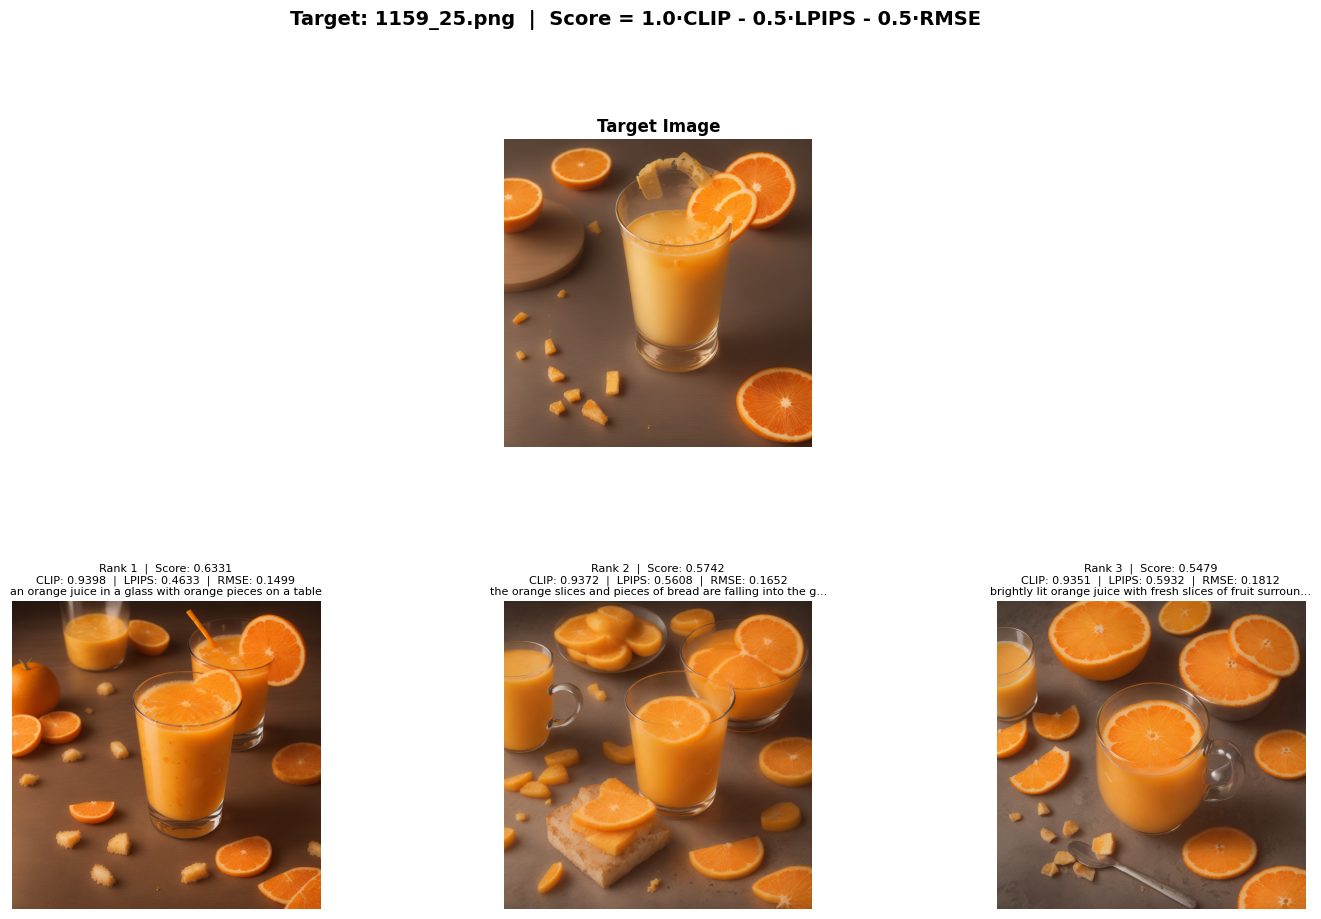

----------------------------------------------------------------------


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=5.54151952e-01, nonzero=1769427


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=4.55929369e-01, nonzero=1769390


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=4.44644362e-01, nonzero=1769409


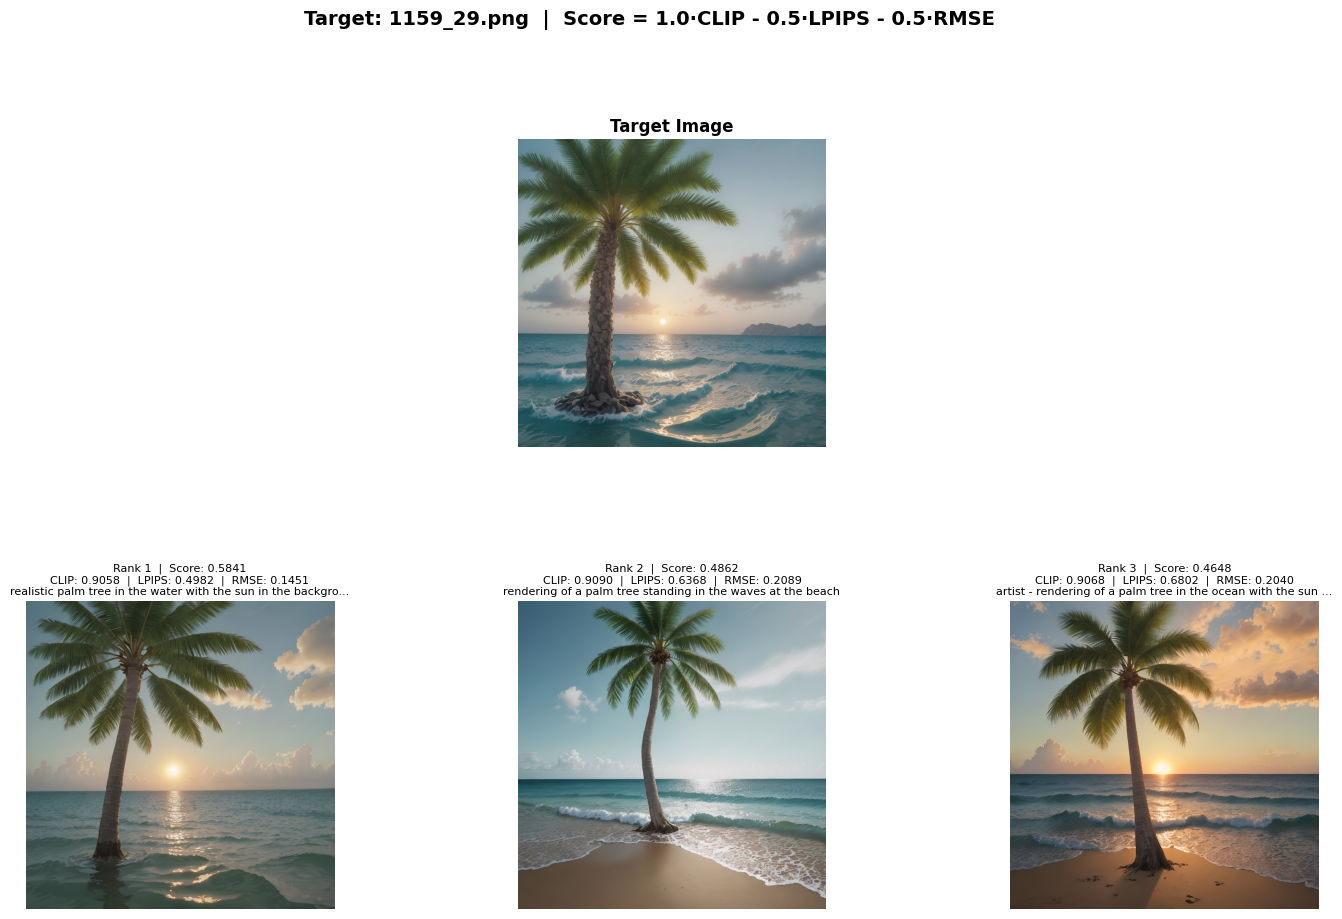

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', dramatic low light , high contrast rim lighting , dark fantasy anime game art , detailed reflective armor , moody digital painting']


----------------------------------------------------------------------


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=2.26713583e-01, nonzero=1769243


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=2.15894014e-01, nonzero=1769301


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=3.43484461e-01, nonzero=1768911


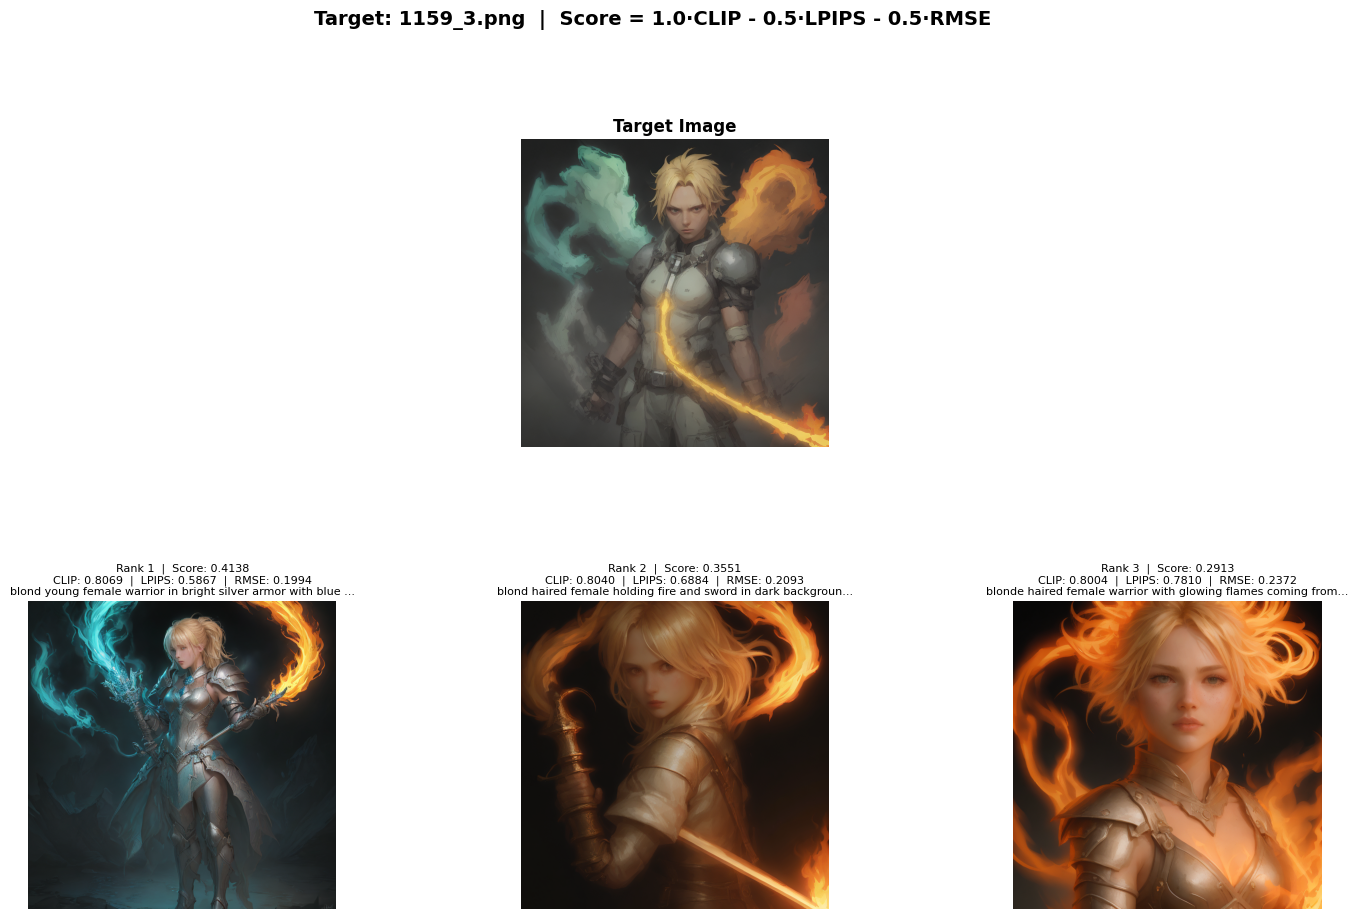

----------------------------------------------------------------------


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=8.06757212e-02, max=8.98835599e-01, mean=4.81800675e-01, nonzero=1769472


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=1.63345337e-02, max=8.77068520e-01, mean=5.15863001e-01, nonzero=1769472


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=1.15447134e-01, max=8.84463370e-01, mean=5.47025561e-01, nonzero=1769472


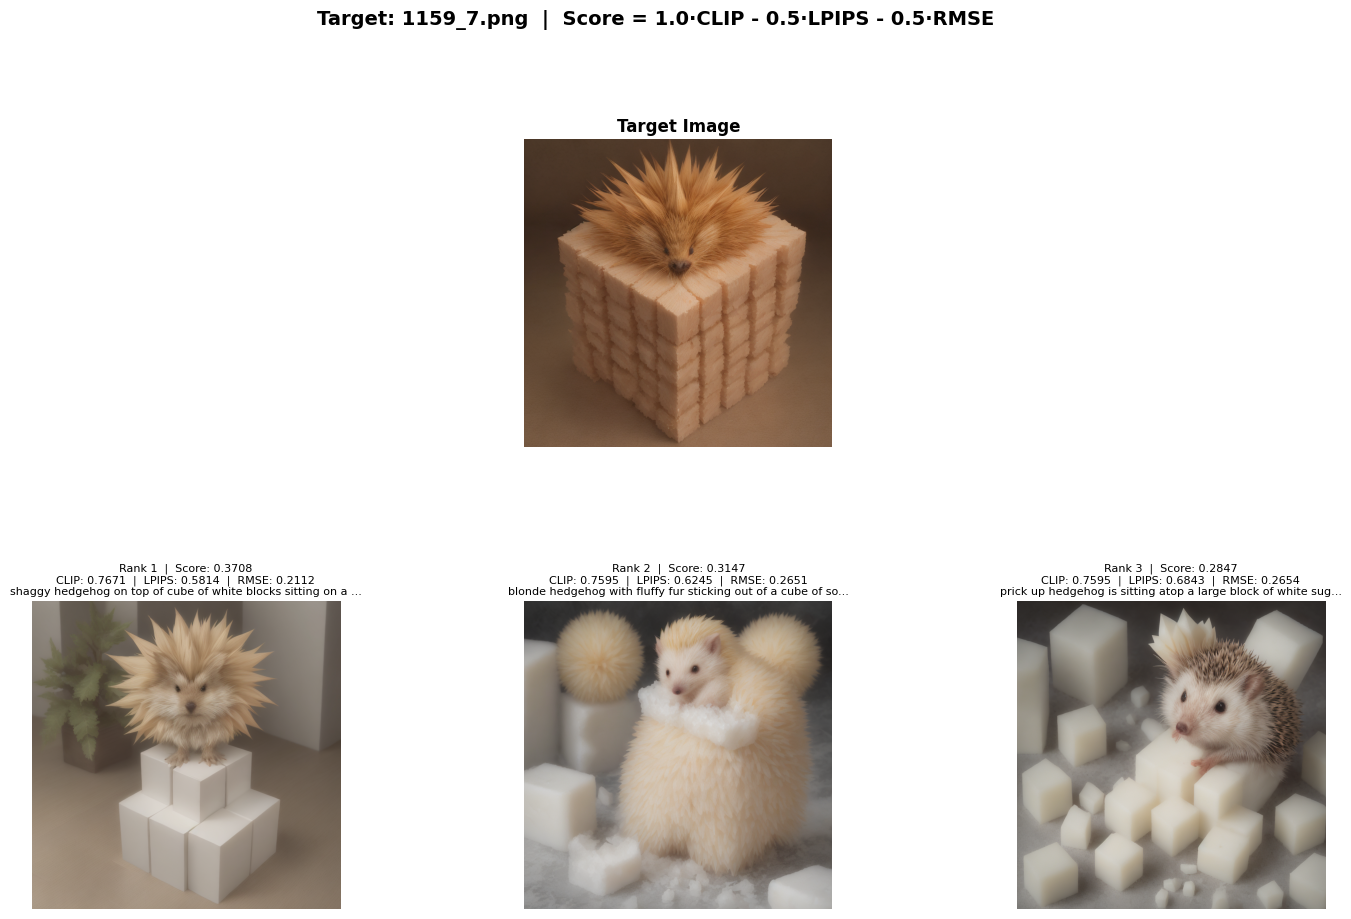

----------------------------------------------------------------------


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=1.07256643e-01, nonzero=1685271


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=1.05688252e-01, nonzero=1734453


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=1.00000000e+00, mean=7.49143213e-02, nonzero=1687795


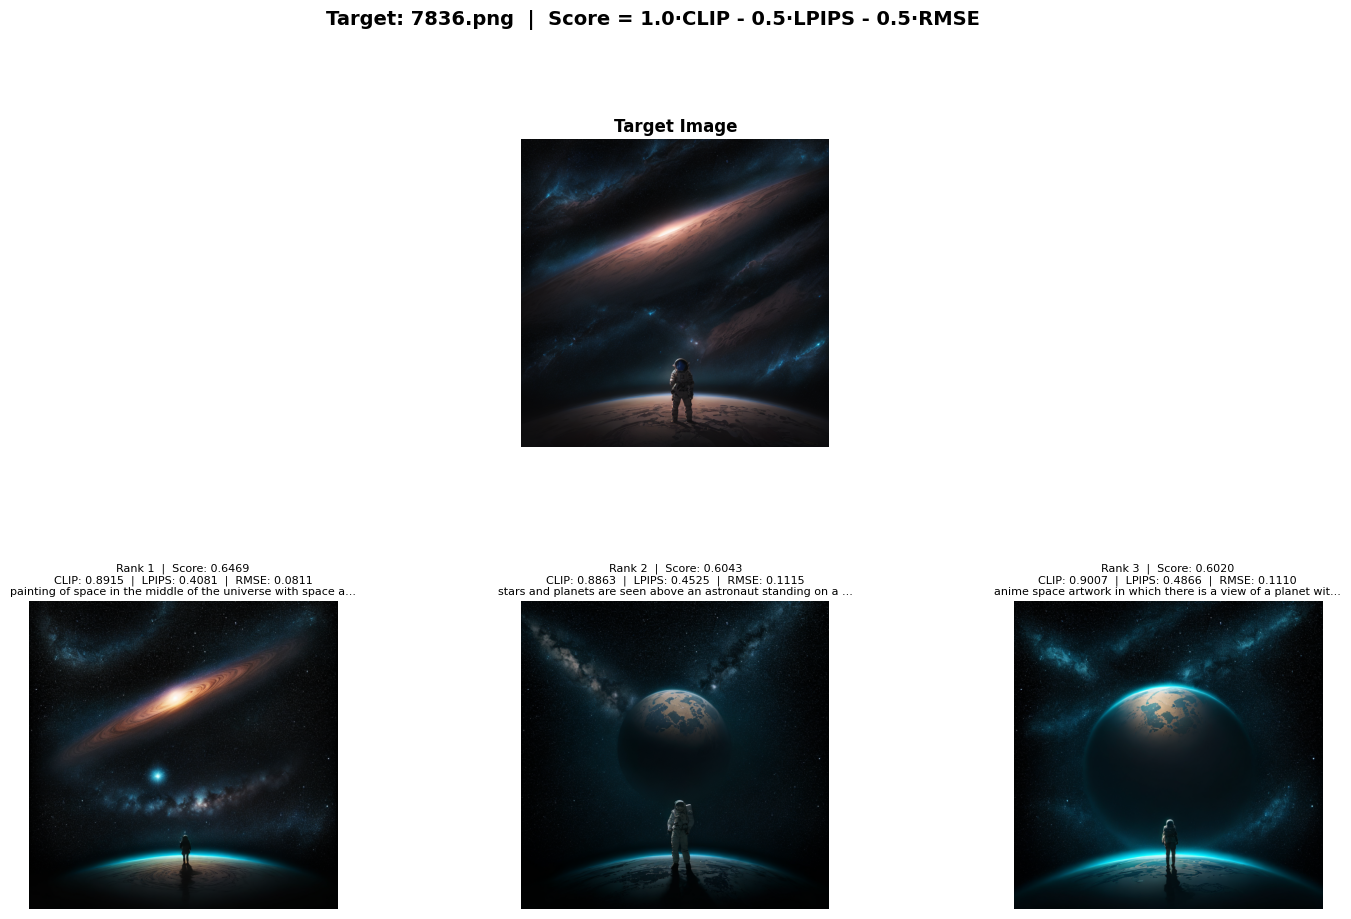

----------------------------------------------------------------------


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=9.79522765e-01, mean=4.77936208e-01, nonzero=1769419


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=8.89291584e-01, mean=4.22049493e-01, nonzero=1769471


  0%|          | 0/8 [00:00<?, ?it/s]

generated raw type: <class 'numpy.ndarray'> dtype: float32 shape: (768, 768, 3)
generated image range: min=0.00000000e+00, max=9.61502433e-01, mean=2.72611260e-01, nonzero=1769454


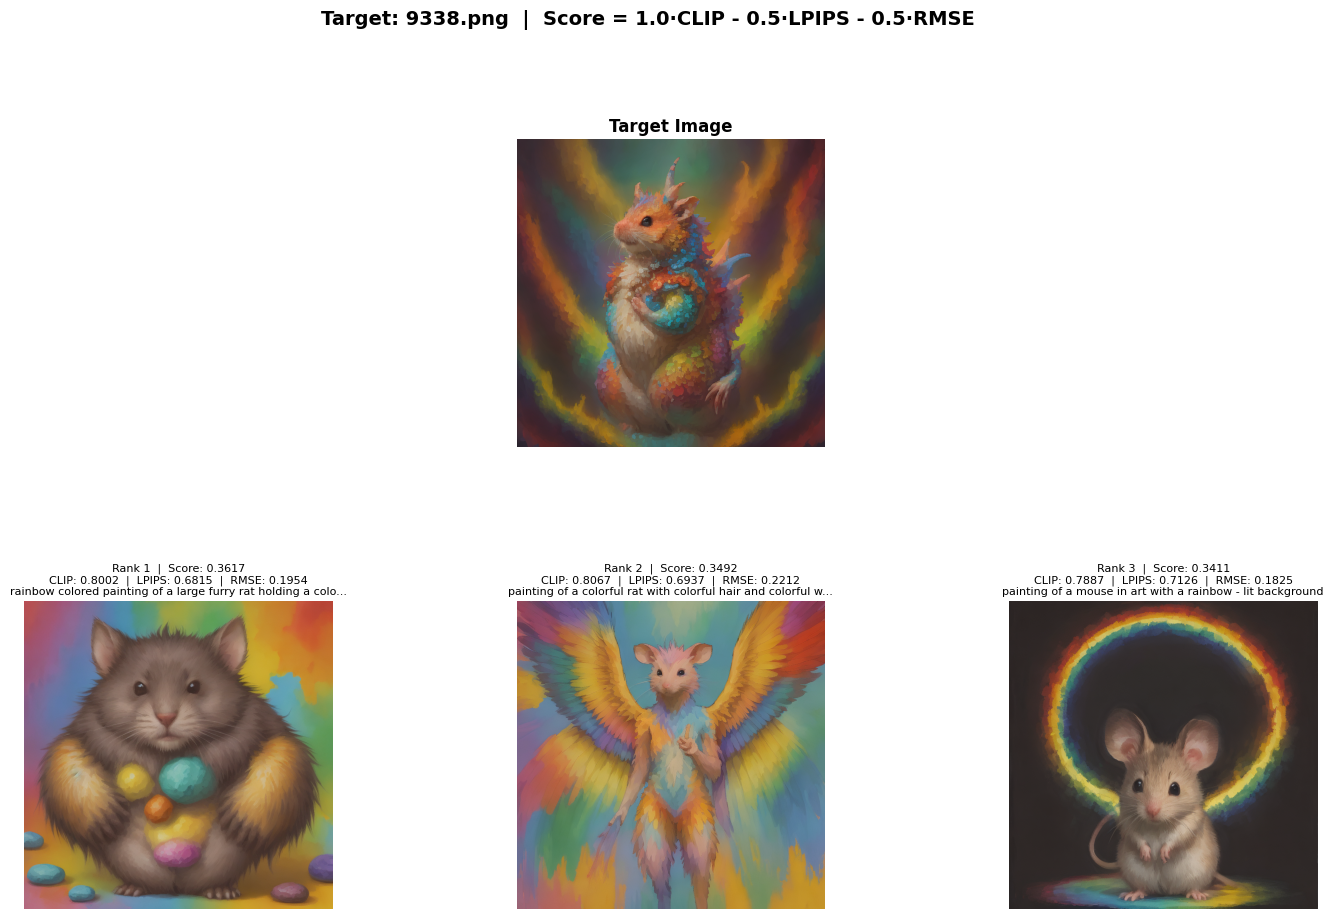

----------------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Composite scoring weights
SCORE_ALPHA = 1.0   # weight for CLIP similarity    (higher = better)
SCORE_BETA  = 0.5   # weight for LPIPS perceptual   (lower = better)
SCORE_GAMMA = 0.5   # weight for MSE pixel error   (lower = better)

def composite_score(clip_sim, lpips, mse):
    """Compute a composite score for ranking candidates.
    Score = alpha * CLIP_sim - beta * LPIPS - gamma * MSE
    Higher score = better candidate.
    """
    mse = float(np.sqrt(mse))
    return SCORE_ALPHA * clip_sim - SCORE_BETA * lpips - SCORE_GAMMA * mse

# Save results from LLM-based refinement: renders, best prompts, and metrics
if 'final_prompts_by_target' not in globals() or not final_prompts_by_target:
    print("[ERROR] final_prompts_by_target not found. Please run the LLM refinement cell first.")
else:
    output_base_dir = Path("outputs/final_submission")
    output_base_dir.mkdir(parents=True, exist_ok=True)

    render_fn = _resolve_renderer()
    all_results = []

    print(f"Saving renders and metrics for all candidates...\n")

    for target_path in target_images:
        target_path = Path(target_path)
        target_name = target_path.name
        target_stem = target_path.stem
        target_image = load_image(target_path)
        seed = seed_from_filename(target_path, config.seed)

        prompts = final_prompts_by_target.get(target_name, [])[:3]

        # Render and calculate metrics for all candidates
        candidates = []
        for i, prompt in enumerate(prompts, 1):
            generated_image = render_fn(prompt, seed=seed, config=config)

            clip_sim  = clip_image_similarity(target_image, generated_image)
            pixel_mse = mse_between_images(target_image, generated_image, size=None)
            lpips_dist = lpips_between_images(target_image, generated_image, device=device)
            score = composite_score(clip_sim, lpips_dist, pixel_mse)

            candidates.append({
                "prompt": prompt,
                "image": generated_image,
                "clip_similarity": clip_sim,
                "pixel_mse": pixel_mse,
                "lpips": lpips_dist,
                "score": score,
            })

        # Sort candidates by composite score (highest = rank 1)
        candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)

        # Save images and record results with the TRUE rank
        target_dir = output_base_dir / target_stem
        target_dir.mkdir(parents=True, exist_ok=True)

        for rank, candidate in enumerate(candidates, 1):
            image_path = target_dir / f"rank_{rank}.png"
            candidate["image"].save(image_path)
            candidate["rank"] = rank
            candidate["saved_path"] = str(image_path)

            all_results.append({
                "Target": target_name,
                "Rank": rank,
                "Prompt": candidate["prompt"],
                "CLIP Similarity": candidate["clip_similarity"],
                "Pixel MSE": candidate["pixel_mse"],
                "LPIPS": candidate["lpips"],
                "Composite Score": candidate["score"],
                "Saved Path": candidate["saved_path"],
            })

        # --- Visual display: target on top, candidates below sorted by score ---
        fig = plt.figure(figsize=(18, 10))
        fig.suptitle(f"Target: {target_name}  |  Score = {SCORE_ALPHA}·CLIP - {SCORE_BETA}·LPIPS - {SCORE_GAMMA}·MSE",
                     fontsize=14, fontweight="bold", y=1.01)

        gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5)
        ax_target = fig.add_subplot(gs[0, 1])
        ax_target.imshow(target_image)
        ax_target.set_title("Target Image", fontsize=12, fontweight="bold")
        ax_target.axis("off")

        for rank, candidate in enumerate(candidates, 1):
            ax = fig.add_subplot(gs[1, rank - 1])
            ax.imshow(candidate["image"])

            prompt_display = candidate["prompt"]
            if len(prompt_display) > 60:
                prompt_display = prompt_display[:60] + "..."

            ax.set_title(
                f"Rank {rank}  |  Score: {candidate['score']:.4f}\n"
                f"CLIP: {candidate['clip_similarity']:.4f}  |  LPIPS: {candidate['lpips']:.4f}  |  MSE: {np.sqrt(candidate['pixel_mse']):.4f}\n"
                f"{prompt_display}",
                fontsize=8,
                wrap=True
            )
            ax.axis("off")

        plt.tight_layout()
        plt.show()
        print("-" * 70)


In [ ]:
import numpy as np

# Per-target metric table + mean and std dev across the 3 candidates
if not all_results:
    print("[ERROR] No results found. Run the save/visualize cell first.")
else:
    # Group results by target
    results_by_target = {}
    for r in all_results:
        results_by_target.setdefault(r["Target"], []).append(r)

    for target_name, candidates in results_by_target.items():
        # Sort by rank for display
        candidates = sorted(candidates, key=lambda x: x["Rank"])

        print("=" * 75)
        print(f"  TARGET: {target_name}")
        print("=" * 75)
        print(f"  {'Rank':<6} {'CLIP (↑)':>12} {'LPIPS (↓)':>12} {'MSE (↓)':>12}  Prompt")
        print("-" * 75)

        clip_vals  = []
        lpips_vals = []
        mse_vals  = []

        for c in candidates:
            mse = float(np.sqrt(c["Pixel MSE"]))
            clip_vals.append(c["CLIP Similarity"])
            lpips_vals.append(c["LPIPS"])
            mse_vals.append(mse)

            prompt_short = c["Prompt"][:40] + "..." if len(c["Prompt"]) > 40 else c["Prompt"]
            print(f"  {c['Rank']:<6} {c['CLIP Similarity']:>12.4f} {c['LPIPS']:>12.4f} {mse:>12.4f}  {prompt_short}")

        # Mean and std dev across the 3 candidates for this target
        print("-" * 75)
        print(f"  {'Mean':<6} {np.mean(clip_vals):>12.4f} {np.mean(lpips_vals):>12.4f} {np.mean(mse_vals):>12.4f}")
        print(f"  {'Std':<6} {np.std(clip_vals):>12.4f} {np.std(lpips_vals):>12.4f} {np.std(mse_vals):>12.4f}")
        print()


NameError: name 'all_results' is not defined